In [11]:

import torch
from torch import nn
import numpy as np

from typing import Any, List
from pathlib import Path

from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Any



In [12]:
# set random seed
np.random.seed(42)
torch.manual_seed(42)


In [ ]:
class PositionalEncoding(nn.Module):
   

    def __init__(
        self,
        d_model: int = 128,
        maxlen: int = 1024,
        min_freq: float = 1e-4,
        device: str = "cpu",
        dtype=torch.float32,
    ):
        super().__init__()
        pos_enc = self._get_pos_enc(d_model=d_model, maxlen=maxlen, min_freq=min_freq)
        self.register_buffer(
            "pos_enc", torch.tensor(pos_enc, dtype=dtype, device=device)
        )

    def _get_pos_enc(self, d_model: int, maxlen: int, min_freq: float):
        position = np.arange(maxlen)
        freqs = min_freq ** (2 * (np.arange(d_model) // 2) / d_model)
        pos_enc = position[:, None] * freqs[None]
        pos_enc[:, ::2] = np.cos(pos_enc[:, ::2])
        pos_enc[:, 1::2] = np.sin(pos_enc[:, 1::2])
        return pos_enc

    def forward(self, x):
        return self.pos_enc[x]


class GaussianFourierProjection(nn.Module):

    def __init__(self, embed_dim: int, scale: float = 1.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.scale = scale
        self.W = torch.randn(self.embed_dim // 2) * self.scale

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * 3.1415927
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class DiscreteTimeResidualBlock(nn.Module):

    def __init__(self, d_model: int, maxlen: int = 512):
        super().__init__()
        self.d_model = d_model
        self.emb = PositionalEncoding(d_model=d_model, maxlen=maxlen)
        self.lin1 = nn.Linear(d_model, d_model)
        self.lin2 = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.act = nn.GELU()

    def forward(self, x, t):
        return self.norm(x + self.lin2(self.act(self.lin1(x + self.emb(t)))))


class BasicDiscreteTimeModel(nn.Module):
    def __init__(self, d_model: int = 128, n_layers: int = 2):
        super().__init__()
        self.d_model = d_model
        self.n_layers = n_layers
        self.lin_in = nn.Linear(2, d_model)
        self.lin_out = nn.Linear(d_model, 2)
        self.blocks = nn.ParameterList(
            [DiscreteTimeResidualBlock(d_model=d_model) for _ in range(n_layers)]
        )

    def forward(self, x, t):
        x = self.lin_in(x)
        for block in self.blocks:
            x = block(x, t)
        return self.lin_out(x)

<>:39: SyntaxWarning: invalid escape sequence '\i'
<>:39: SyntaxWarning: invalid escape sequence '\i'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_27008\3818966940.py:39: SyntaxWarning: invalid escape sequence '\i'
  """Positional encoding for continuum states. Think how to embed


In [14]:
class DDIM(nn.Module):

    def __init__(self, n_steps: int, minval: float = 1e-5, maxval: float = 5e-3):
        super().__init__()
        assert 0 < minval < maxval <= 1
        assert n_steps > 0
        self.n_steps = n_steps
        self.minval = minval
        self.maxval = maxval
        self.register_buffer("beta", torch.linspace(minval, maxval, n_steps))
        self.register_buffer("alpha", 1 - self.beta)
        self.register_buffer("alpha_bar", self.alpha.cumprod(0))

    def diffusion_loss(self, model: nn.Module, inp: torch.Tensor) -> torch.Tensor:
        device = inp.device
        batch_size = inp.shape[0]

        # create the noise perturbation
        eps = torch.randn_like(inp, device=device)

        # convert discrete time into a positional encoding embedding
        t = torch.randint(0, self.n_steps, (batch_size,), device=device)

        # compute the closed form sample x_noisy after t time steps
        a_t = self.alpha_bar[t][:, None]
        x_noisy = torch.sqrt(a_t) * inp + torch.sqrt(1 - a_t) * eps

        # predict the noise added given time t
        eps_pred = model(x_noisy, t)

        # Gaussian posterior, i.e. learn the Gaussian kernel.
        return nn.MSELoss()(eps_pred, eps)

    def ddpm_sample(self, model: nn.Module, n_samples: int = 128):
        with torch.no_grad():
            device = next(model.parameters()).device

            # start off with an intial random ensemble of particles
            x = torch.randn(n_samples, 2, device=device)

            # the number of steps is fixed before beginning training. unfortunately.
            for t in reversed(range(self.n_steps)):
                # apply the same variance to all particles in the ensemble equally.
                a = self.alpha[t].repeat(n_samples)[:, None]
                abar = self.alpha_bar[t].repeat(n_samples)[:, None]

                # deterministic trajectory. eps_theta is similar to the Force on the particle
                eps_theta = model(x, torch.tensor([t] * n_samples, dtype=torch.long))
                x_mean = (x - eps_theta * (1 - a) / torch.sqrt(1 - abar)) / torch.sqrt(
                    a
                )
                sigma_t = torch.sqrt(1 - self.alpha[t])

                # sample a different realization of noise for each particle and propagate
                z = torch.randn_like(x)
                x = x_mean + sigma_t * z

            return x_mean  # clever way to skip the last noise addition


    def ddim_sample(self, model: nn.Module, n_samples: int = 128):

      with torch.no_grad():
        device = next(model.parameters()).device
        x = torch.randn(n_samples, 2, device=device)

        # number of DDIM steps (about 20)
        ddim_steps = min(20, self.n_steps)
        # create a uniform sequence of timesteps from T-1 down to 0
        timesteps = np.linspace(0, self.n_steps - 1, ddim_steps, endpoint=True)
        timesteps = np.round(timesteps).astype(np.int64)
        timesteps = np.unique(timesteps)[::-1]   # descending, unique, ensures 0 is included

        # iterate over the chosen timesteps
        for i in range(len(timesteps) - 1):
            t = timesteps[i]          # current time step (larger)
            s = timesteps[i + 1]      # next time step (smaller)

            # get alpha_bar for t and s
            alpha_bar_t = self.alpha_bar[t]
            alpha_bar_s = self.alpha_bar[s]

            # predicted noise at time t
            t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)
            eps_theta = model(x, t_tensor)

            # DDIM update rule (eta = 0, deterministic)
            sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
            sqrt_alpha_bar_s = torch.sqrt(alpha_bar_s)
            sqrt_one_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar_t)
            sqrt_one_minus_alpha_bar_s = torch.sqrt(1 - alpha_bar_s)

            # predict x0 from x_t
            x0_pred = (x - sqrt_one_minus_alpha_bar_t * eps_theta) / sqrt_alpha_bar_t
            # compute x_s
            x = sqrt_alpha_bar_s * x0_pred + sqrt_one_minus_alpha_bar_s * eps_theta

        return x

In [15]:
def train(
    model: nn.Module,
    diffuser: DDIM,
    batch_size: int = 128,
    n_epochs: int = 400,
    sample_size: int = 512,
    seed: int = 42
    ):

    np.random.seed(seed)
    torch.manual_seed(seed)

    N = 1024
    X = make_swiss_roll(n_samples=N, noise=1e-1)[0][:, [0, 2]] / 10.0
    print("dataset size", X.shape) # total dataset, [1024, 2]

    optim = torch.optim.Adam(model.parameters(), 1e-3)

    losses: List[float] = []
    ddpm_samples: List[Any] = []
    ddim_samples: List[Any] = []

    with tqdm(total=n_epochs) as pbar:
        for e in range(n_epochs):
            ids = np.random.choice(N, N, replace=False) # shuffle the dataset
            loss_epoch = []
            for i in range(0, len(ids), batch_size):
                x = torch.tensor(X[ids[i : i + batch_size]], dtype=torch.float32)
                optim.zero_grad()
                loss = diffuser.diffusion_loss(model, x)
                loss.backward()
                optim.step()
                loss_epoch.append(loss.item())

            avg_loss = np.mean(loss_epoch)
            pbar.update(1)
            pbar.set_description(f"Epoch: {e}. Average Loss: {avg_loss:.04f}")
            losses.append(avg_loss)
            ddpm_samples.append(diffuser.ddpm_sample(model, n_samples=sample_size))
            ddim_samples.append(diffuser.ddim_sample(model, n_samples=sample_size))

    return losses, ddpm_samples, ddim_samples


def show_loss(losses: List[float]):
    fig = plt.figure()
    plt.plot(losses)
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()


def show_samples(samples: List[Any], epochs: List[int], rows = 2):
    columns = int(np.ceil(len(epochs)/rows))
    fig = plt.figure(figsize = (4 * columns, 4 * rows))
    for i, epoch in enumerate(epochs):
        plt.subplot(rows, columns, i + 1)
        plt.scatter(samples[epoch][:, 0], samples[epoch][:, 1], c="k", alpha=0.3)
        plt.title(f"Samples on epoch {epoch}")
    plt.show()


In [16]:

n_steps: int = 100
d_model: int = 128
n_layers: int = 2
batch_size: int = 128
n_epochs: int = 401
sample_size: int = 512
seed: int = 42

model = BasicDiscreteTimeModel(d_model=d_model, n_layers=n_layers)
diffuser = DDIM(n_steps=n_steps)
losses, ddpm_samples, ddim_samples = train(
    model=model,
    diffuser=diffuser,
    batch_size=batch_size,
    n_epochs=n_epochs,
    sample_size=sample_size,
    seed=seed,
)


dataset size (1024, 2)


Epoch: 400. Average Loss: 0.6738: 100%|██████████| 401/401 [01:16<00:00,  5.22it/s]


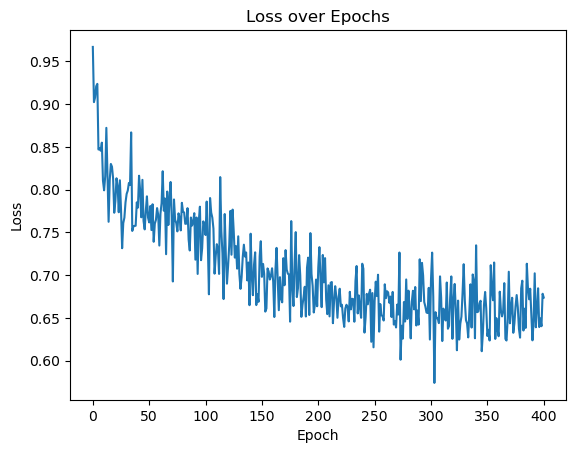

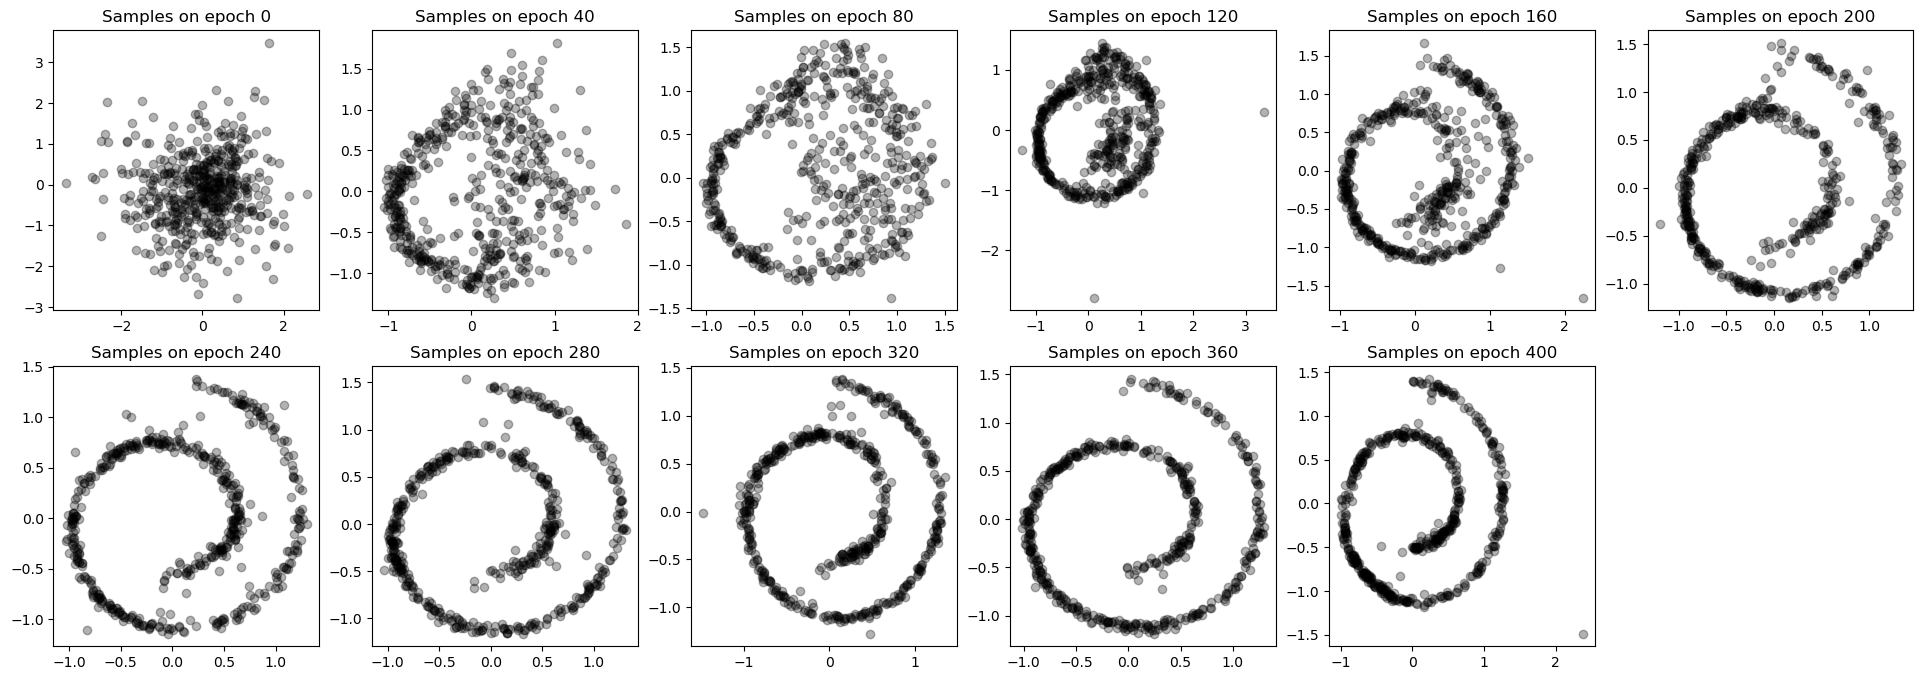

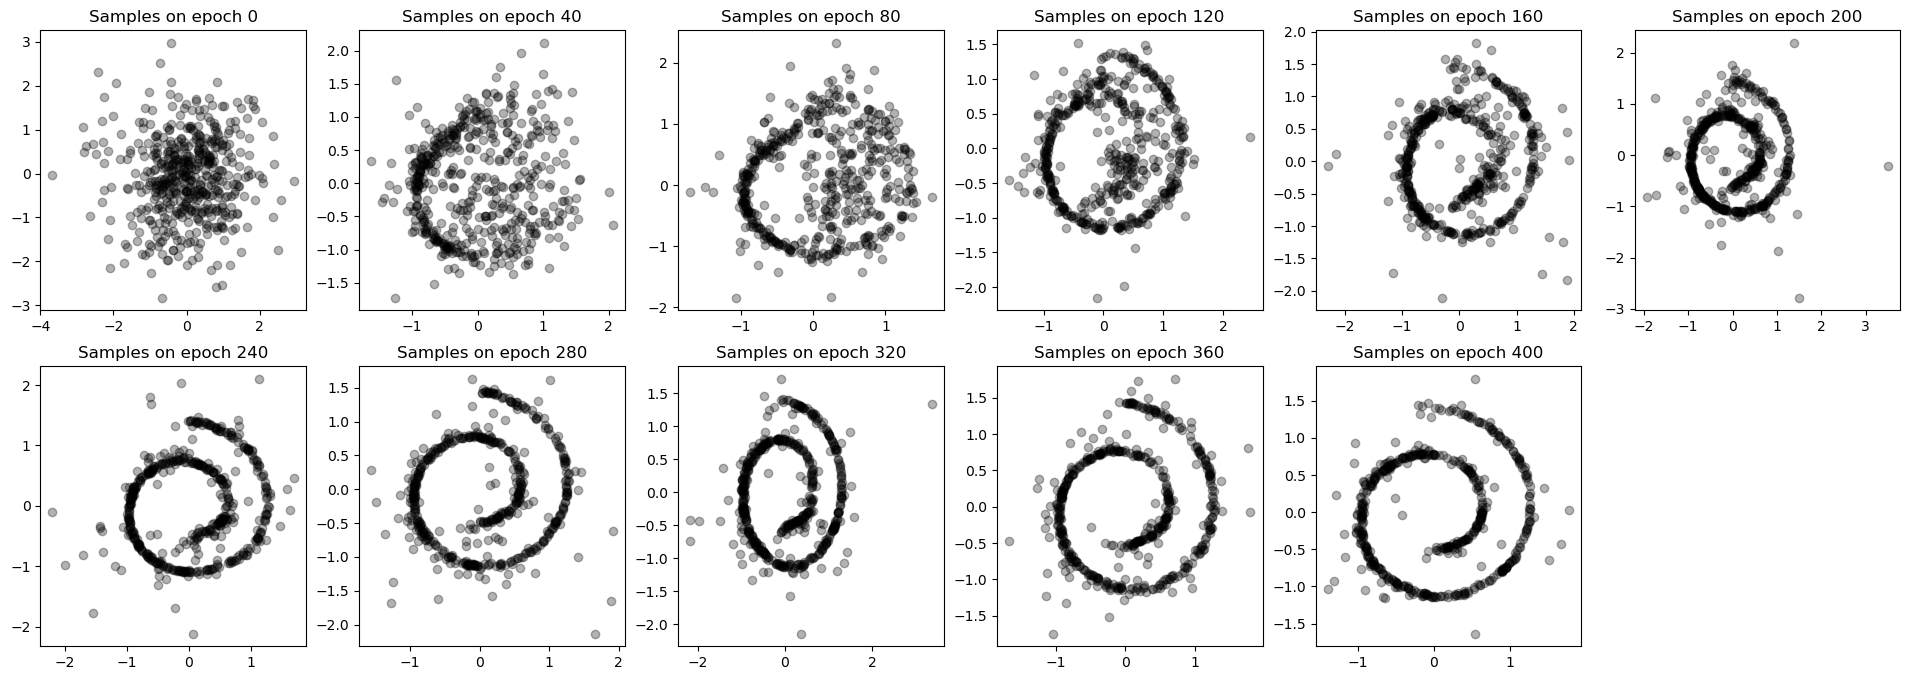

In [17]:
show_loss(losses)
show_samples(ddpm_samples, list(range(0, n_epochs, n_epochs // 10)))
show_samples(ddim_samples, list(range(0, n_epochs, n_epochs // 10)))